In [54]:
import numpy as np
import matplotlib.pyplot as plt

In [55]:
points = np.array([[1, 5], [3, 7], [7, 6], [9, 10]])
x = points[:, 0]
y = points[:, 1]

In [56]:
def cubic_spline_interpolation(x, y):
    n = len(x)
    num_segments = n - 1

    # --- Step 1: interval widths ---
    h = np.zeros(num_segments)
    for i in range(num_segments):
        h[i] = x[i+1] - x[i]

    # --- Step 2: Build tridiagonal system for c[1..n-2] ---
    # c[0] = c[n-1] = 0  (natural spline)
    size = n - 2   # number of unknowns: c1, c2, ..., c_{n-2}

    A   = np.zeros((size, size))
    rhs = np.zeros(size)

    for i in range(size):
        # i here corresponds to knot index (i+1) in the full array
        A[i, i] = 2 * (h[i] + h[i+1])
        if i > 0:
            A[i, i-1] = h[i]
        if i < size - 1:
            A[i, i+1] = h[i+1]

        rhs[i] = 3 * ((y[i+2] - y[i+1]) / h[i+1] - (y[i+1] - y[i]) / h[i])

    # --- Step 3: Solve ---
    c_inner = np.linalg.solve(A, rhs)

    # --- Step 4: Pad with boundary values ---
    c = np.zeros(n)          # c[0] = c[n-1] = 0 already
    c[1:n-1] = c_inner

    # --- Step 5: Back-calculate a, b, d ---
    a = np.zeros(num_segments)
    b = np.zeros(num_segments)
    d = np.zeros(num_segments)

    for i in range(num_segments):
        a[i] = y[i]
        d[i] = (c[i+1] - c[i]) / (3 * h[i])
        b[i] = (y[i+1] - y[i]) / h[i] - h[i] * (2*c[i] + c[i+1]) / 3

    return a, b, c[:-1], d

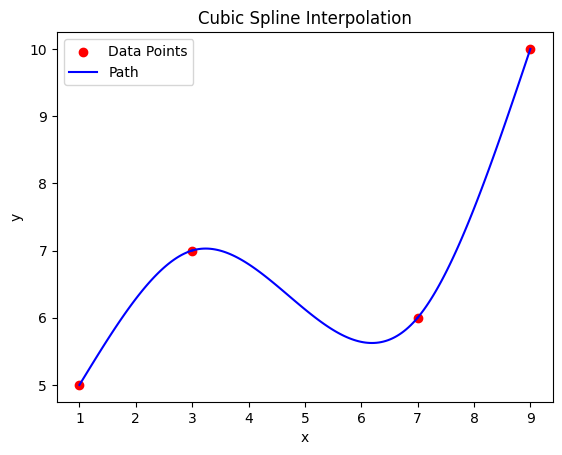

In [57]:
fig,axis = plt.subplots()
axis.scatter(x, y, color='red', label='Data Points')
a, b, c, d = cubic_spline_interpolation(x, y)
num_segments = len(a)
for i in range(num_segments):
    x_segment = np.linspace(x[i], x[i+1], 100)
    dx = x_segment - x[i]
    y_segment = a[i] + b[i]*dx + c[i]*dx**2 + d[i]*dx**3
    axis.plot(x_segment, y_segment, color='blue', label = "Path" if i == 0 else "")
axis.set_title('Cubic Spline Interpolation')
axis.set_xlabel('x')
axis.set_ylabel('y')
axis.legend()
plt.show()